In [1]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import skimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu

plt.style.use('styleNB.mplstyle')


def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell', 'position']):
        d_ = d_.copy().sort_values('interval')
        interval_frames = d_.interval.values[::frame_step]
        sampled = d_[d_['interval'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    return df_out

In [2]:
df_1 = pd.read_csv('../../data/processed_2D_tracking/20250406_isolated_zebrafish_keratocytes_tracking_filtered.csv')
df_2 = pd.read_csv('../../data/processed_2D_tracking/20250420_isolated_zebrafish_keratocytes_tracking_filtered.csv')
df = pd.concat([df_1, df_2], ignore_index=True)
df = df[df.E_V_cm != 5]

# Step 1: unit correction
## Note that videos were tracked in units of pixels. Conversion factors:
# Rio scope (AP samples): 1.547 pixels/um
# Oslo scope (NB samples): 1.530 pixel/um

# Make a copy to avoid modifying the original DataFrame in-place (optional but safe)
df_converted = df.copy()

# Apply conversion factor: NB = 1.53, AP = 1.547
df_converted.loc[df_converted['user'] == 'NB', ['x', 'y']] /= 1.53
df_converted.loc[df_converted['user'] == 'AP', ['x', 'y']] /= 1.547
df_converted['celltype'] = df_converted['celltype_genotype']
df = df_converted

df = df[df.E_V_cm != 5]

df.head()

,Unnamed: 0,cell,frame,x,y,z,celltype,position,E_V_cm,date,trial,user,celltype_genotype
0,0,0,0,349.024110,196.442253,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
1,1,0,1,359.114003,194.286702,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
2,2,0,2,369.991581,196.799344,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
3,3,0,3,380.458097,202.806752,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
4,4,0,4,383.005824,214.212646,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT


In [3]:

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype_genotype', 'E_V_cm', 'date', 'trial', 'user', 'cell', 'position']):
    frames = sorted(d_.frame.unique())
    
    # Filter: skip short tracks
    if len(frames) <= 10:
        continue

    min_frame = min(frames)
    d_ = d_.copy()
    d_['rel_frame'] = d_.frame - min_frame

    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)  # full resolution

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])
    
    positions = np.array(positions)
    if np.isnan(positions).any():
        continue

    # # Filter: ignore any non-moving cells 
    total_movement = np.sum(np.sqrt(np.sum(np.diff(positions, axis=0)**2, axis=1)))
    if total_movement < 20:
        continue

    # Keep untrimmed full-resolution track
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'position': g[-1],
            'interval': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)    

df_filtered_tracks['frame'] = df_filtered_tracks['interval']



# Plotting 

## Tracks

('Galvanin_KO', 0)
('Galvanin_KO', 1)
('Galvanin_KO', 3)
('Galvanin_WT', 0)
('Galvanin_WT', 1)
('Galvanin_WT', 3)


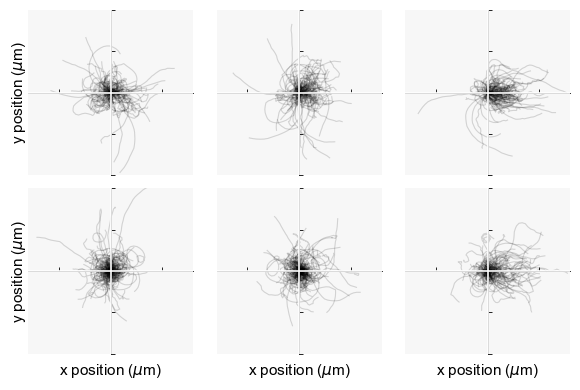

In [5]:
f, ax = plt.subplots(2, 3, figsize=(6, 4))
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}


for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):
        if len(d_) < 5:
            continue
        if count_cell > 126:
            continue


        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        # Optional: mark final point faintly
        #ax_.scatter(x_rel[-1], y_rel[-1], s=2, color='black', alpha=0.1, zorder=5)

        count_cell += 1

    ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-400, 400)
    ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    ax_.set_xlabel(r'x position ($\mu$m)')
    ax_.set_ylabel(r'y position ($\mu$m)')

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Hide x labels if not in bottom row
        if r < n_rows - 1:
            ax_.set_xlabel('')
            ax_.tick_params(labelbottom=False)

        # Hide y labels if not in leftmost column
        if c > 0:
            ax_.set_ylabel('')
            ax_.tick_params(labelleft=False)

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Keep axis labels only on outer left and bottom
        if r < n_rows - 1:
            ax_.set_xlabel('')
        if c > 0:
            ax_.set_ylabel('')

        # Remove all tick labels
        ax_.set_xticklabels([])
        ax_.set_yticklabels([])

        # Optional: reduce tick mark length
        ax_.tick_params(length=3)
            
plt.tight_layout()


<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_60311/2643721333.py:53: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('x position ($\mu$m)')
/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_60311/2643721333.py:54: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('y position ($\mu$m)')


Processing group: ('Galvanin_KO', 0)


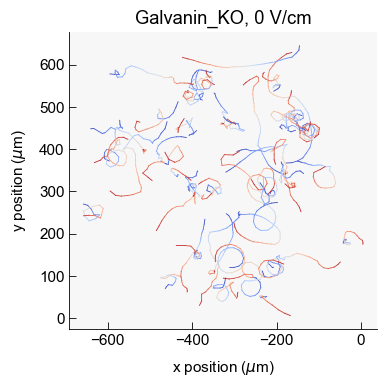

Processing group: ('Galvanin_KO', 1)


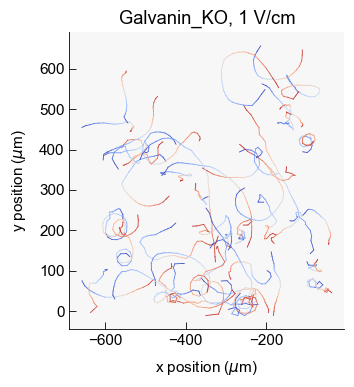

Processing group: ('Galvanin_KO', 3)


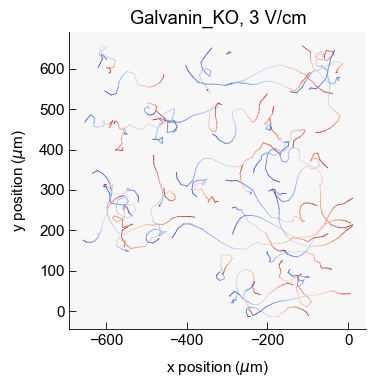

Processing group: ('Galvanin_WT', 0)


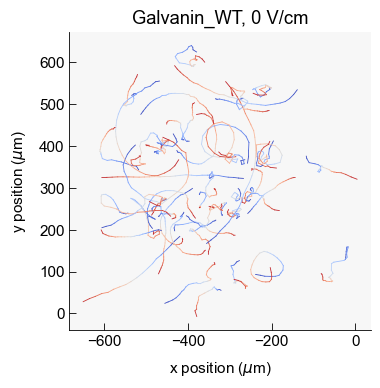

Processing group: ('Galvanin_WT', 1)


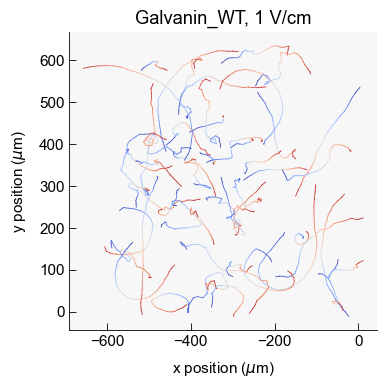

Processing group: ('Galvanin_WT', 3)


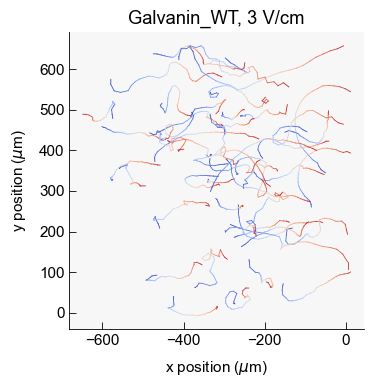

In [9]:

# Mapping for subplots
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}

# Set image pixel to micron scale
ip = 0.642

# Number of trajectories per group to plot
n_cells_per_group = 50

# Colormap for time progression
cmap = plt.get_cmap('coolwarm')

for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    print(f"Processing group: {g}")
    
    # Collect valid trajectories
    valid_cells = []
    for cell_id, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):
        if len(d_) < 15:
            continue
        valid_cells.append(d_)
    
    if not valid_cells:
        continue

    # Randomly sample up to 50 valid cells
    random.seed(0)
    sampled_cells = random.sample(valid_cells, min(len(valid_cells), n_cells_per_group))

    # Create figure
    fig, ax = plt.subplots(figsize=(4, 4))

    for d_ in sampled_cells:
        # Transform x and y coordinates
        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values
        time = np.arange(len(x))

        # Normalize time for color mapping
        norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))

        # Draw line segments with color gradient
        for i in range(len(x) - 1):
            ax.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)

    # Axis settings
    ax.set_xlabel('x position ($\mu$m)')
    ax.set_ylabel('y position ($\mu$m)')
    ax.set_title(f'{g[0]}, {g[1]} V/cm')
    ax.set_aspect('equal')
    ax.set_facecolor('#f7f7f7')
    # ax.set_xlim(-400, 400)
    # ax.set_ylim(-400, 400)
    # ax.axhline(0, color='white', lw=1.2, zorder=100)
    # ax.axvline(0, color='white', lw=1.2, zorder=100)
    # ax.spines['left'].set_position(('data', 0))
    # ax.spines['bottom'].set_position(('data', 0))
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

## Here are only plots of 300 mV/mm condition only - probably more useful for main text figures. (two examples)

Processing group: ('Galvanin_KO', 3)
Processing group: ('Galvanin_WT', 3)


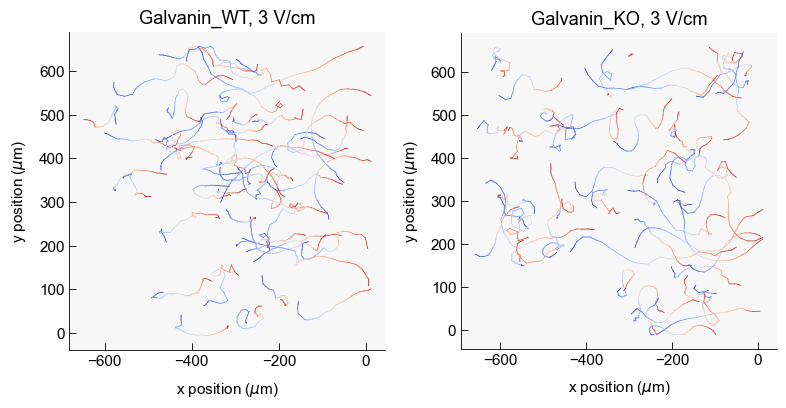

In [60]:

# Mapping for subplots
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}

# Set image pixel to micron scale
ip = 0.642

# Number of trajectories per group to plot
n_cells_per_group = 50

# Colormap for time progression
cmap = plt.get_cmap('coolwarm')

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for g, d in df_filtered_tracks[df_filtered_tracks.E_V_cm == 3].groupby(['celltype', 'E_V_cm']):
    print(f"Processing group: {g}")
    
    # Collect valid trajectories
    valid_cells = []
    for cell_id, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):
        if len(d_) < 15:
            continue
        valid_cells.append(d_)
    
    if not valid_cells:
        continue

    # Randomly sample up to 50 valid cells
    random.seed(0)
    sampled_cells = random.sample(valid_cells, min(len(valid_cells), n_cells_per_group))


    for d_ in sampled_cells:
        # Transform x and y coordinates
        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values
        time = np.arange(len(x))

        # Normalize time for color mapping
        norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))

        # Draw line segments with color gradient
        for i in range(len(x) - 1):
            ax[dict_ax[g[0]]].plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)

    # Axis settings
    for ax_ in [ax[dict_ax[g[0]]]]: 
        ax_.set_xlabel(r'x position ($\mu$m)')
        ax_.set_ylabel(r'y position ($\mu$m)')
        ax_.set_title(f'{g[0]}, {g[1]} V/cm')
        ax_.set_aspect('equal')
        ax_.set_facecolor('#f7f7f7')
    # ax.set_xlim(-400, 400)
    # ax.set_ylim(-400, 400)
    # ax.axhline(0, color='white', lw=1.2, zorder=100)
    # ax.axvline(0, color='white', lw=1.2, zorder=100)
    # ax.spines['left'].set_position(('data', 0))
    # ax.spines['bottom'].set_position(('data', 0))
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Processing group: ('Galvanin_KO', 3)
Processing group: ('Galvanin_WT', 3)


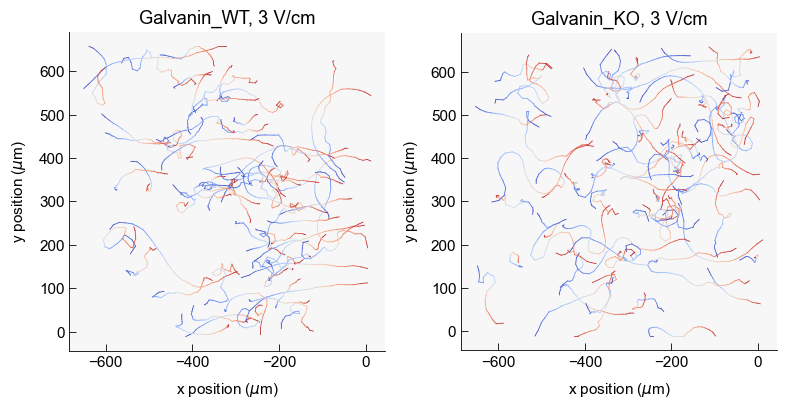

In [61]:

# Mapping for subplots
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}

# Set image pixel to micron scale
ip = 0.642

# Number of trajectories per group to plot
n_cells_per_group = 70

# Colormap for time progression
cmap = plt.get_cmap('coolwarm')

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for g, d in df_filtered_tracks[df_filtered_tracks.E_V_cm == 3].groupby(['celltype', 'E_V_cm']):
    print(f"Processing group: {g}")
    
    # Collect valid trajectories
    valid_cells = []
    for cell_id, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):
        if len(d_) < 15:
            continue
        valid_cells.append(d_)
    
    if not valid_cells:
        continue

    # Randomly sample up to 50 valid cells
    random.seed(50)
    sampled_cells = random.sample(valid_cells, min(len(valid_cells), n_cells_per_group))


    for d_ in sampled_cells:
        # Transform x and y coordinates
        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values
        time = np.arange(len(x))

        # Normalize time for color mapping
        norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))

        # Draw line segments with color gradient
        for i in range(len(x) - 1):
            ax[dict_ax[g[0]]].plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)

    # Axis settings
    for ax_ in [ax[dict_ax[g[0]]]]: 
        ax_.set_xlabel(r'x position ($\mu$m)')
        ax_.set_ylabel(r'y position ($\mu$m)')
        ax_.set_title(f'{g[0]}, {g[1]} V/cm')
        ax_.set_aspect('equal')
        ax_.set_facecolor('#f7f7f7')
    # ax.set_xlim(-400, 400)
    # ax.set_ylim(-400, 400)
    # ax.axhline(0, color='white', lw=1.2, zorder=100)
    # ax.axvline(0, color='white', lw=1.2, zorder=100)
    # ax.spines['left'].set_position(('data', 0))
    # ax.spines['bottom'].set_position(('data', 0))
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Speed related

In [40]:
# Step 1: Define interval (number of frames between points)
interval = 2

# Step 2: subsample
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)

colors = sns.color_palette("tab10")
color_dict = dict(zip(['Galvanin_WT', 'Galvanin_KO','',''
                       , ''], colors))  

color_dict.update({'Galvanin_WT':'#B8BABC'})


# Plot directed speed along x-axis
colors = sns.color_palette("tab10")
color_dict = {
    'Galvanin_WT': '#B8BABC',
    'Galvanin_KO': colors[1],
    '': colors[2]  
    }


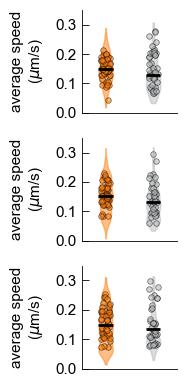

In [41]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = sorted(df_intervals['E_V_cm'].unique())
field_strengths = [e for e in field_strengths] 

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]
    #print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user', 'position'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                # Use 2D or 3D displacement depending on z availability
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60)  # μm/sec
                

                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
            # print(speed_prep)

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=5
                )
                speed_all.extend(speed_prep)
                #print(f"  {celltype}: {len(speed_prep)} cells, mean {np.mean(speed_prep):.4f}")

        # Plot violin if there’s data
        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=2, zorder=10)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    a.set_ylim(0, 0.35)
    a.set_yticks([0.0, 0.1, 0.2, 0.3])
    a.set_ylabel('average speed\n' + r'($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()

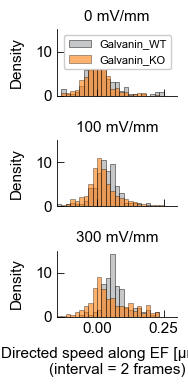

In [68]:
bins = np.linspace(-0.15, 0.25, 25)
E_field_values = sorted(df_intervals['E_V_cm'].unique())
celltypes = sorted(df_intervals['celltype'].unique())

fig, axs = plt.subplots(nrows=len(E_field_values), ncols=1, figsize=(2, 4), sharex=True, sharey=True)
if len(E_field_values) == 1:
    axs = [axs]

for idx, E in enumerate(E_field_values):
    ax = axs[idx]
    df_temp = df_intervals[df_intervals['E_V_cm'] == E]

    for celltype in reversed(celltypes):
        dot = []
        df_cell = df_temp[df_temp['celltype'] == celltype]

        for _, d in df_cell.groupby(['date', 'trial', 'user', 'cell', 'position']):
            d = d.sort_values('interval')
            if len(d) < 2:
                continue

            dx = np.diff(d['x'].values)
            mean_dx = np.mean(dx)
            directed_speed = mean_dx / (interval * 60.0)  # μm/sec 
            dot.append(directed_speed)

        if len(dot) > 0:
            alpha = 0.8 if celltype == 'Galvanin_WT' else 0.6
            ax.hist(dot, bins=bins, density=True, alpha=alpha,
                    edgecolor='black', linewidth=0.4,
                    label=celltype, color=color_dict.get(celltype, 'gray'))

    ax.set_xlim(-0.15, 0.3)
    ax.set_title(str(int(E)*100)+' mV/mm', fontsize = 11)
    if idx == 0:
        ax.legend(fontsize=8)

axs[-1].set_xlabel(f'Directed speed along EF [μm/min]\n(interval = {interval} frames)')
for ax in axs:
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()


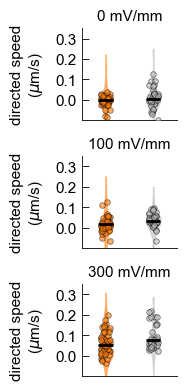

In [67]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = sorted(df_intervals['E_V_cm'].unique())
field_strengths = [e for e in field_strengths]

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user', 'position'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                x = d['x'].values
                dx = np.diff(x)
                speed_x = dx / (interval * 60)  # μm/sec

                if len(speed_x) > 0:
                    speed_prep.append(np.mean(speed_x))

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=5
                )
                speed_all.extend(speed_prep)

        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=2, zorder=10)
            ax[ax_idx].set_title(str(int(E)*100)+' mV/mm', fontsize = 11)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    a.set_ylim(-0.1, 0.35)  # extend min y-limit for possible negative speeds
    a.set_yticks([0.0, 0.1, 0.2, 0.3])
    a.set_ylabel('directed speed\n' + r'($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()

# Directionality (average cosine theta)

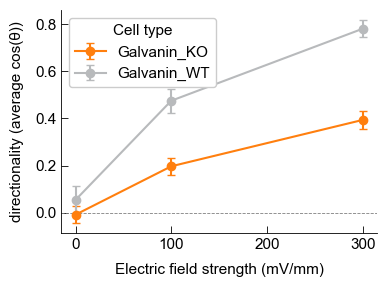

In [75]:
def calc_cos_theta_net_per_trajectory(df):
    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'position', 'cell']
    results = []

    for name, group in df.groupby(group_cols):
        dx = group['x'].iloc[-1] - group['x'].iloc[0]
        dy = group['y'].iloc[-1] - group['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])
        norm = np.linalg.norm(v)

        cos_theta = np.nan if norm == 0 else np.dot(v, e_field) / norm

        # name is a tuple matching group_cols
        row = dict(zip(group_cols, name))
        row['cos_theta_net'] = cos_theta
        results.append(row)

    return pd.DataFrame(results)


df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(figsize=(4,3))

for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax.errorbar(
        group['E_V_cm'] * 100,  # convert to mV/mm if needed
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=3,
        lw=1.5,
        color = color_dict[celltype]
    )

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('directionality (average cos(θ))')
# ax.set_title('Alignment of Net Trajectory with Electric Field')
ax.legend(title='Cell type')
plt.tight_layout()
plt.show()

# Autocorrelation Analysis

## Using cosine theta between trajectory vector and electric field.

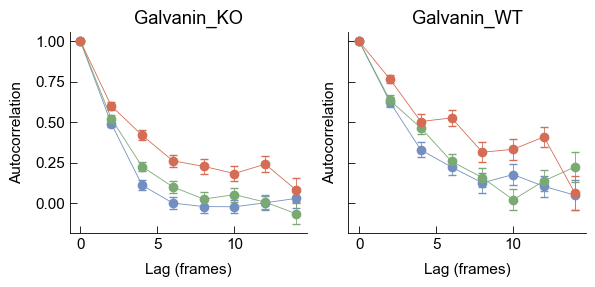

In [43]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr


autocorr_list = []
for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'position', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 2,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(3*len(celltypes),3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]  # same across lags if consistent
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})", capsize=3, marker='o'
        )
    ax.set_title(celltype)
    ax.set_xlabel('Lag (frames)')
    ax.set_ylabel('Autocorrelation')
    # ax.legend()
plt.tight_layout()
plt.show()

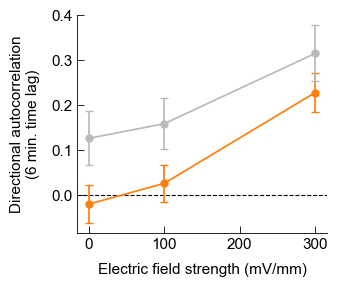

In [55]:
lag_to_plot = 8#6  # in frames; 6-minute lag corresponds to lag=6 frames at 1-minute intervals

df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot]  

fig, ax = plt.subplots(figsize=(3.5, 3))

for g, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')
    
    ax.errorbar(
        x=d_sorted.E_V_cm.values * 100,  # converting to mV/mm
        y=d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
        marker='o', markersize=5, lw=1.25, capsize=3, zorder=10, color = color_dict[g]
    )

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)

# ax.set_xlim(-5, 350)
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('Directional autocorrelation\n(6 min. time lag)')

# ax.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)

plt.tight_layout()
plt.show()



## Autocorrelation, but relative to 0 mV/mm condition.

Here we plot relative to the 0 mV/mm condition to try to account for residual persistence in the absence of an electric field.  (i.e. subtraction of autocorrelation value from the 0 mV/mm condition).

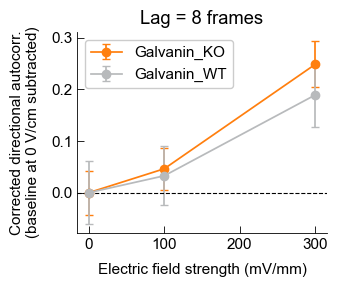

In [57]:
# --- 1. Corrected Autocorrelation Plot ---
fig1, ax1 = plt.subplots(figsize=(3.5, 3))

for celltype, group in df_plot.groupby('celltype'):
    baseline_val = baseline.get(celltype, np.nan)
    if pd.isna(baseline_val):
        continue  # skip if baseline missing

    d_sorted = group.sort_values('E_V_cm')
    corrected = d_sorted['mean_autocorr'] - baseline_val

    ax1.errorbar(
        d_sorted.E_V_cm * 100,  # convert to mV/mm
        corrected,
        yerr=d_sorted.sem_autocorr,  # keep SEM as is
        label=celltype,
        marker='o', capsize=3, lw=1.25,
        color=color_dict.get(celltype, 'gray')
    )

ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Electric field strength (mV/mm)')
ax1.set_ylabel('Corrected directional autocorr.\n(baseline at 0 V/cm subtracted)')
ax1.set_title(f'Lag = {lag_to_plot} frames')
ax1.legend()
plt.tight_layout()
plt.show()